# 边

## 意图识别的条件边

In [1]:
from langgraph.graph import StateGraph, START, END
from typing_extensions import TypedDict

# 定义状态
class IntentState(TypedDict):
    user_input: str
    user_intent: str
    response: str

# 意图识别节点
def intent_recognition_node(state):
    user_input = state['user_input'].lower()
    # 简单的意图识别逻辑
    if '天气' in user_input or 'weather' in user_input:
        intent = "查询天气"
    elif '机票' in user_input or 'flight' in user_input:
        intent = "预订机票"
    elif '投诉' in user_input or 'complaint' in user_input:
        intent = "投诉建议"
    else:
        intent = "未知"
    
    return {"user_intent": intent}

# 技能节点
def weather_query_node(state):
    return {"response": "今天天气晴朗，温度 22-28°C"}

def flight_booking_node(state):
    return {"response": "为您查找合适的机票选项..."}

def complaint_suggestion_node(state):
    return {"response": "感谢您的反馈，我们会认真处理您的建议"}

# 条件路由函数
def route_to_skill(state):
    """条件函数，根据用户意图路由到不同的技能节点"""
    user_intent = state['user_intent']
    if user_intent == "查询天气":
        return "weather_query_node"  # 跳转到查询天气节点
    elif user_intent == "预订机票":
        return "flight_booking_node"  # 跳转到预订机票节点
    elif user_intent == "投诉建议":
        return "complaint_suggestion_node"  # 跳转到投诉建议处理节点
    else:
        return END  # 无法识别意图，结束流程

# 构建图
builder = StateGraph(IntentState)

# 添加节点
builder.add_node("intent_recognition_node", intent_recognition_node)
builder.add_node("weather_query_node", weather_query_node)
builder.add_node("flight_booking_node", flight_booking_node)
builder.add_node("complaint_suggestion_node", complaint_suggestion_node)

# 添加边
builder.add_edge(START, "intent_recognition_node")
builder.add_conditional_edges(
    "intent_recognition_node", 
    route_to_skill,
    ["weather_query_node", "flight_booking_node", "complaint_suggestion_node", END]
)
builder.add_edge("weather_query_node", END)
builder.add_edge("flight_booking_node", END)
builder.add_edge("complaint_suggestion_node", END)

# 编译图
intent_graph = builder.compile()

print("意图识别与技能路由图构建完成")

# 测试不同的用户输入
test_inputs = [
    "今天天气怎么样？",
    "我要预订明天到北京的机票",
    "我要投诉你们的服务",
    "你好"
]

for user_input in test_inputs:
    print(f"\n用户输入: {user_input}")
    result = intent_graph.invoke({"user_input": user_input})
    print(f"识别意图: {result.get('user_intent', '未识别')}")
    print(f"系统回复: {result.get('response', '无回复')}")

意图识别与技能路由图构建完成

用户输入: 今天天气怎么样？
识别意图: 查询天气
系统回复: 今天天气晴朗，温度 22-28°C

用户输入: 我要预订明天到北京的机票
识别意图: 预订机票
系统回复: 为您查找合适的机票选项...

用户输入: 我要投诉你们的服务
识别意图: 投诉建议
系统回复: 感谢您的反馈，我们会认真处理您的建议

用户输入: 你好
识别意图: 未知
系统回复: 无回复


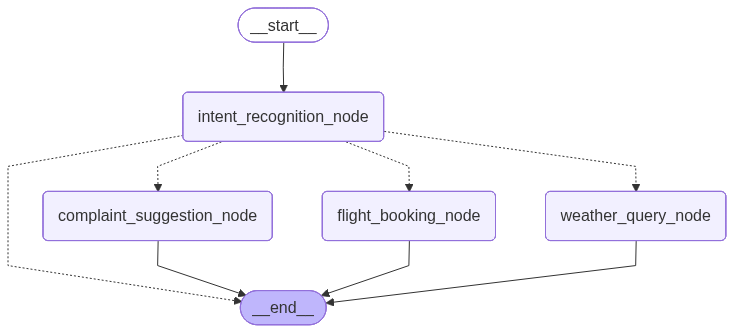

In [4]:
from IPython.display import Image, display

try:
    display(Image(intent_graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass